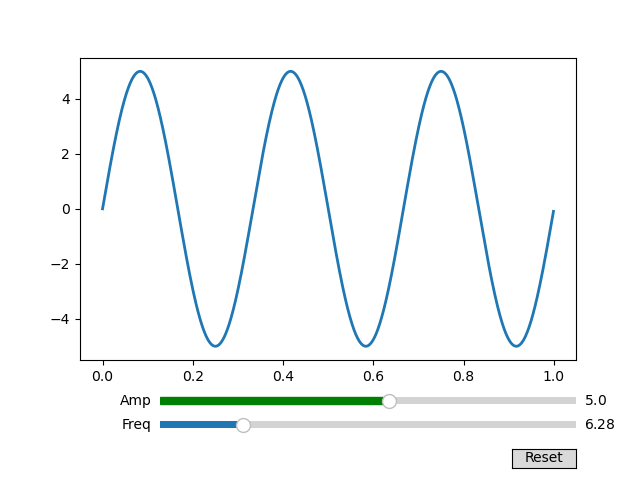

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget
from matplotlib.widgets import Button, Slider

t = np.arange(0.0, 1.0, 0.001)
a0 = 5
f0 = 3
s = a0 * np.sin(2 * np.pi * f0 * t)

fig, ax = plt.subplots()
fig.subplots_adjust(bottom=0.25)
l, = ax.plot(t, s, lw=2)

ax_freq = fig.add_axes((0.25, 0.1, 0.65, 0.03))
ax_amp = fig.add_axes((0.25, 0.15, 0.65, 0.03))

# define the values to use for snapping
allowed_amplitudes = np.concatenate([np.linspace(.1, 5, 100), [6, 7, 8, 9]])

# create the sliders
samp = Slider(
    ax_amp, "Amp", 0.1, 9.0,
    valinit=a0, valstep=allowed_amplitudes,
    color="green"
)

sfreq = Slider(
    ax_freq, "Freq", 0, 10*np.pi,
    valinit=2*np.pi, valstep=np.pi,
    initcolor='none'  # Remove the line marking the valinit position.
)


def update(val):
    amp = samp.val
    freq = sfreq.val
    l.set_ydata(amp*np.sin(2*np.pi*freq*t))
    fig.canvas.draw_idle()


sfreq.on_changed(update)
samp.on_changed(update)

ax_reset = fig.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(ax_reset, 'Reset', hovercolor='0.975')


def reset(event):
    sfreq.reset()
    samp.reset()
button.on_clicked(reset)


plt.show()
